# Musterlösung 11

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 - Gradientenverfahren

## a)

Laden Sie zuerst die Daten aus dem File 'decay.txt'. Sie enthalten eine Spannung, die exponentiell mit der Zeit zerfällt,

$$ V(t) = Ae^{-\frac{t}{\tau}},$$

sowie deren Unsicherheiten. Stellen Sie die Werte mit Fehlerbalken dar, und schätzen Sie die Amplitude $A$ und die Zerfallszeit $\tau$  ab, indem Sie sie aus der Grafik ablesen.

### Lösung

Bei t = 0s ist V = 5.79 V, also A = 5.79 V
Dabei ist  V(0)/e = 2.13 V und schlussendlich tau = 0.2 s 


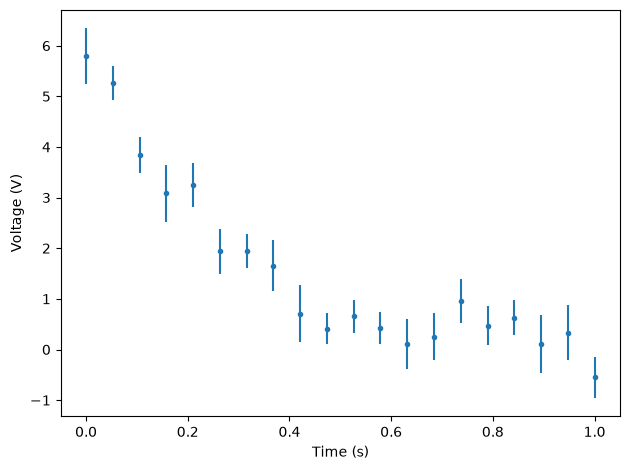

In [4]:
data = np.loadtxt('Ex11/decay.txt', skiprows=1)
t = data[0, :]
V = data[1, :]
sigma = data[2, :]


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='None')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

fig.tight_layout()

print('Bei t = 0s ist V = {:0.2f} V, also A = {:0.2f} V'.format(V[0], V[0]))
print('Dabei ist  V(0)/e = {:0.2f} V und schlussendlich tau = 0.2 s '.format(V[0]/np.exp(1)))

## b)

Schreiben Sie zuerst eine Funktion $f(x,\vec{a})$, die das Modell beschreibt.

Anschliessend definieren Sie die Funktion, die

$$S = \sum_{n=0}^{m} \frac{(y_i - f(x_i, \vec{a}))^2}{\sigma_i^2}$$

berechnet. Sie sollte $x$, $y$, $\sigma$, $f$ und $\vec{a}$ als Argumente nehmen und $S$ zurückgeben. Benutzen Sie die Funktion, um $S$ für verschiedene Parameter $\vec{a}$ um die Werte herum zu berechnen, die Sie in a) abgeschätzt haben (je ca. 50 Punkte sollten genügen). Plotten Sie $\log(S)$ in einer 2D Grafik (Analog zur Übung 10). 


### Lösung

In [5]:
def exp(t, a):
    return a[0] * np.exp(-t / a[1]) #a[0] = A, a[1] = tau

def Sres(x, y, sigma, f, a):
    return np.sum((y - f(x,a))**2 / sigma**2)

In [6]:
# Wir definieren die Testwerte rund um unsere Schätzung der vorherigen Aufgabe. 
A_range = np.linspace(5, 7, 50)
tau_range = np.linspace(0.1, 0.4, 51)

# Array um die Werte zu speichern
S = np.zeros((len(A_range), len(tau_range)))

# Iteration durch die beiden Arrays mit den Testwerten
for i, A in enumerate(A_range):
    for j, tau in enumerate(tau_range):
        S[i, j] = Sres(t, V, sigma, exp, [A, tau])

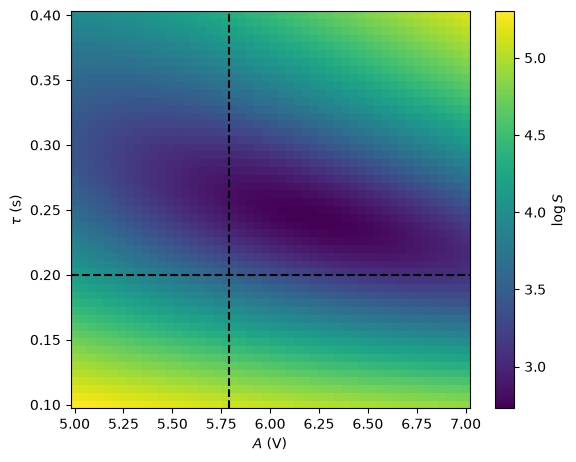

In [7]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

# Wir zeichnen die geschätzten Werte mit Linien ein.
ax.axhline(0.2, color='k', linestyle='--')
ax.axvline(5.79, color='k', linestyle='--')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')

fig.tight_layout()

## c)

Für das Gradientenverfahren benötigen wir die erste und die zweite Ableitung von $S$ bezüglich der Parameter $a_i$. Man kann die erste Ableitung berechnen, indem man die Werte von $\vec{a}$ um einen kleinen Wert $\Delta$ variiert und die Differenz betrachtet. Um die Ableitung nach jedem Parameter separat zu berechnen, definieren wir den Vektor $\vec{\Delta}_i = \Delta \vec{e}_i$, der den Parameter $a_i$ variiert. Damit ergibt sich für die erste Ableitung:

$$
(\vec{\nabla}S)_i = \frac{\partial S}{\partial {a_i}} = \frac{S(x, y, \sigma, f, \vec{a} + \vec{\Delta}_i) - S(x, y, \sigma, f, \vec{a} - \vec{\Delta}_i)}{2\Delta}.
$$

Und die zweite:

$$
(\nabla^\top\nabla S)_{i,j} = \frac{\partial^2 S}{\partial a_i \partial a_j}= \frac{S(x, y, \sigma, f, \vec{a} + \vec{\Delta}_i + \vec{\Delta}_j) - S(x, y, \sigma, f, \vec{a}  - \vec{\Delta}_i + \vec{\Delta}_j) - S(x, y, \sigma, f, \vec{a}  + \vec{\Delta}_i - \vec{\Delta}_j) + S(x, y, \sigma, f, \vec{a}  - \vec{\Delta}_i - \vec{\Delta}_j)}{4\Delta^2}.
$$

Wir stellen eine Funktion für die zweite Ableitung zur Verfügung. Versuchen Sie, die Schritte nachzuvollziehen und schreiben Sie analog dazu eine Funktion, die die erste Ableitung berechnet.

In [8]:
def dS2 (x, y, sigma, f, a, delta):
    # Leere Matrix um die Komponenten zu speichern
    delta_S2 = np.zeros((len(a), len(a)))
    
    # Da wir über alle Kombinationen der a_i's ableiten müssen, iterieren wir in zwei verschachtelten Schlaufen über die
    # Einträge von a. 
    for i in range(len(a)):
        for j in range(len(a)):
            # Wir definieren neue Delta-Vektoren, die nur einen Eintrag in der Entsprechenden Dimension haben z.B. (Delta, 0)
            delta_i = np.zeros(len(a))
            delta_j = np.zeros(len(a))
            delta_i[i] = delta
            delta_j[j] = delta
            
            # Und wir berechnen die Matrixelemente so wie in der Aufgabenstellung gegeben.
            delta_S2[i,j] = (  Sres(x, y, sigma, f, a + delta_i + delta_j)
                             - Sres(x, y, sigma, f, a - delta_i + delta_j)
                             - Sres(x, y, sigma, f, a + delta_i - delta_j)
                             + Sres(x, y, sigma, f, a - delta_i - delta_j)) / (4 * delta * delta)
    return delta_S2

### Lösung

In [9]:
def dS(x, y, sigma, f, a, delta):
    delta_S = np.zeros(len(a))
    
    for i in range(len(a)):
        delta_i = np.zeros(len(a))
        delta_i[i] = delta
        delta_S[i] = (Sres(x, y, sigma, f, a + delta_i) - Sres(x, y, sigma, f, a - delta_i)) / (2 * delta)
        
    return delta_S

## d)

Schreiben Sie nun eine Funktion, die das Gradientenverfahren anwendet, um die optimalen Parameter zu finden. Berechnen Sie dazu zuerst $\vec{\nabla} S$ und dessen Betrag $|dS| = |\vec{\nabla} S|$ für einen Startwert $\vec{a}_0$. Berechnen Sie anschliessend den nächsten Wert $\vec{a} = \vec{a}_0-\alpha\vec{\nabla} S $ mithilfe des Proportionalitätswertes $\alpha$ und dann vom neuen $\vec{a}$ wieder $\vec{\nabla} S$ und $|dS|$. Iterieren Sie nun über diesen Prozess mit einem `while` loop, bis $|dS|$ klein genug ist. Als Alternative sollten Sie auch eine maximale Anzahl Iterationen $i_{\mathrm{max}}$ als Abbruchbedingung definieren, falls die Annäherung zum Minimum zu langsam oder gar nicht konvergiert. Es ist sinnvoll, in einer Fitfunktion auch direkt die Kovarianzmatrix zu berechnen, dazu können Sie die Funktion `np.linalg.inv` benutzen.

Die Funktion sollte also folgende Argumente nehmen: $x$, $y$, $\sigma$, $f$, $\vec{a}_0$, $\Delta$, $\alpha$, $|dS|_{min}$ und $i_{max}$. Die Funktion sollte die optimalen Parameter sowie die Kovarianzmatrix als Resultate zurückgeben. Zudem sollte sie auch noch $|dS|$ für jede Iteration speichern und zusammen mit der Anzahl ausgeführten Iterationen zurückgeben.

### Lösung

In [10]:
def gradient_descent(x, y, sigma, f, a0, delta, alpha, mingrad, imax):
    # a für die erste iteration
    a_next = a0
    
    # Berechnen des Gradienten
    current_gradient = dS(x, y, sigma, f, a_next, delta)
    
    # Berechnen der Norm des Gradienten
    norm = [np.linalg.norm(current_gradient)]
    
    # Speichern der Parameter (Bonus Aufgabe)
    a = np.zeros((int(imax),2))
    a[0] = a_next
    
    # Initialisieren der Iterationsvariablen
    i = 0
    while norm[i] > mingrad and i <= imax:
        # Parameter für die nächste Iteration
        a_next = a_next - alpha * current_gradient
        
        # Gradient und Norm berechnen
        current_gradient = dS(x, y, sigma, f, a_next, delta)
        norm.append(np.linalg.norm(current_gradient))
        a[i] = a_next
        i += 1 
        
    # Die Kovarianzmatrix ergibt sich aus der invertierten zweiten Ableitung.
    cov = 2*np.linalg.inv(dS2(x, y, sigma, f, a_next, delta))
    
    # Wir entfernen die überzählingen Nullen am Ende des Arrays
    a = a[:i, :]
    return a_next, cov, norm, i, a

## e)

Fitten Sie nun die Parameter mit dem Gradientenverfahren. Was sind die optimalen Parameter und ihre Fehler, wie viele Iterationen hat der Algorithmus gebraucht?

Benutzen Sie als Anfangswerte Ihre Abschätzungen von Aufgabe a). Für die restlichen Parameter können Sie die folgenden Werte verwenden, schauen Sie sich aber auch mal an was passiert, wenn Sie diese variieren.

$$
\Delta = 10^{-4}\qquad\alpha = 10^{-5}\qquad{}|dS|_{min} = 10^{-3}\qquad{}i_{max} = 10^{5}
$$

### Lösung

In [11]:
# Anfangsparameter
a0 = [5.79, 0.2]

# Fitparameter
delta = 1e-4
alpha = 1e-5
mingrad = 1e-3
imax = 1e5

# Fitten der Funktion
a_opt, cov, norm, n_iter, a = gradient_descent(t, V, sigma, exp, a0, delta, alpha, mingrad, imax)

# Berechnen der Standardabweichung aus der Kovarianzmatrix
std = np.sqrt(np.diag(cov))

print(u'Die optimalen parameter sind A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0], a_opt[1], std[1]))
print('Es hat {:n} Iterationen benötigt.'.format(n_iter))

Die optimalen parameter sind A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
Es hat 49362 Iterationen benötigt.


## f)

Um die Plausibilität der Fitresultate zu überprüfen, plotten Sie nochmals die Daten mit Fehlerbalken und dazu die Exponentialfunktion mit den berechneten optimalen Parametern. Sie sollten sehen, dass die berechnete Funktion in den meisten Fällen innerhalb der Fehlerbalken liegt. Schauen Sie sich auch an, wie schnell der Fit besser wird, indem Sie $|dS|$ als Funktion des Iterations-Indexes darstellen.

Bonus: Modifizieren Sie Ihre Funktion des Gradientenverfahrens so, dass sie bei jeder Iteration den aktuellen Wert von $\vec{a}$ speichert und zurückgibt. Plotten Sie nun nochmals die 2D Map von Aufgabe b), Sie können nun mit `plt.plot` direkt die Werte von $\vec{a}$ darüber plotten. Damit können Sie direkt verfolgen, welchen Weg das Gradientenverfahren einschlägt.

### Lösung

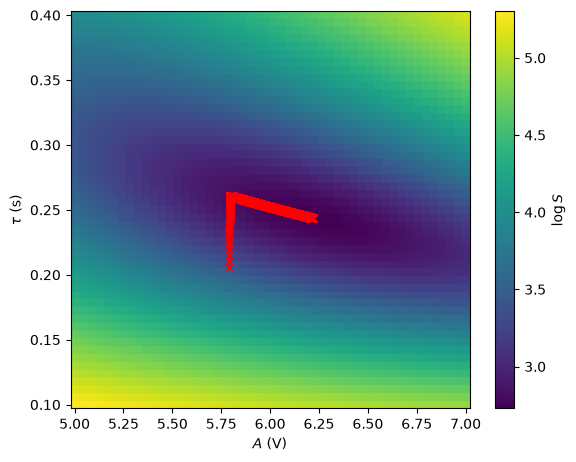

In [12]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))

ax = fig.add_subplot(1, 1, 1)
im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

# Entsprechend unserer Definition entspricht der erste Eintrag der Amplitude und der zweite der Zerfallszeit
ax.plot(a[:, 0], a[:, 1], marker='x', color='r')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')
fig.tight_layout()

## g)

Das Verfahren lässt sich beschleunigen, indem man die Schrittgrösse $\alpha$ proportional zur Steigung von $dS$, also der zweiten Ableitung, skaliert. Die entsprechende Formel für die Parameter ist wie folgt:
$$
a_i = a_{i,0} - \alpha\left(\frac{\partial^2 S}{\partial a_i \partial a_i}\right)^{-1} \frac{\partial S}{\partial a_i}
$$

Schreiben Sie eine neue Funktion, die proportionale Schrittgrössen verwendet, und fitten Sie erneut die Daten. Sie können die gleichen Parameter verwenden, mit Ausnahme von $\alpha=1$. Überprüfen Sie erneut die Qualität des Fits, indem Sie die Funktion mit den optimalen Parametern zusammen mit den Daten plotten. Vergleichen Sie auch, wie schnell $|dS|$ im Vergleich zur obigen Funktion abnimmt.

Bonus: Sie können sich auch hier wieder die Werte von $\vec{a}$ ausgeben lassen und in den 2D Plot einfügen.

###  Lösung

In [13]:
def gradient_descent_adaptive(x, y, sigma, f, a_next, delta, alpha, mingrad, imax):
    # Analog zur bisherigen Funktion
    current_gradient = dS(x, y, sigma, f, a_next, delta)
    norm = [np.linalg.norm(current_gradient)]
    
    # Berechnen der Diagonalelemente der zweiten Ableitung
    h_diag = np.diag(dS2(x, y, sigma, f, a_next, delta))
    a = np.zeros((imax, 2))
    a[0] = a_next
    i = 0
    while norm[i] > mingrad and i <= imax:
        # Skalierung der nächsten Parameter mit der zweiten Ableitung
        a_next = a_next - alpha/(h_diag)*current_gradient
        current_gradient = dS(x, y, sigma, f, a_next, delta)
        norm.append(np.linalg.norm(current_gradient))
        h_diag = np.diag(dS2(x, y, sigma, f, a_next, delta)) 
        i += 1 
        a[i] = a_next
    
    a = a[:i, :]
    cov = 2 * np.linalg.inv(dS2(x, y, sigma, f, a_next, delta))
    return a_next, cov, norm, i, a

In [14]:
a0 = [6, 0.2]
delta = 1e-4
alpha = 1e0
mingrad = 1e-3
imax = 50000

a_opt, cov, norm_adaptive, imax, a= gradient_descent_adaptive(t, V, sigma, exp, a0, delta, alpha, mingrad, imax)
std = np.sqrt(np.diag(cov))

print(u'Die optimalen parameter sind A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0],a_opt[1], std[1]))
print('Es hat {:n} iterationen benötigt'.format(imax))

Die optimalen parameter sind A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
Es hat 31 iterationen benötigt


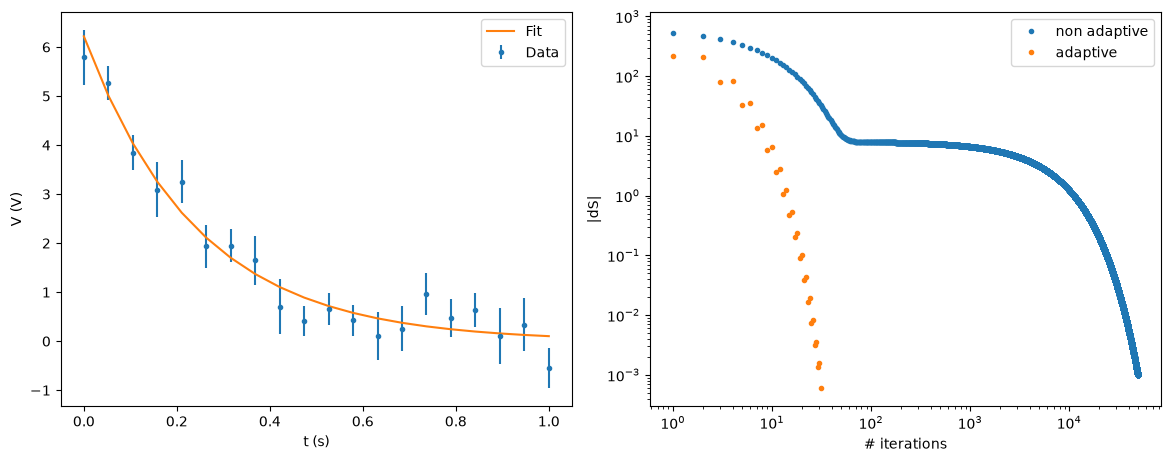

In [15]:
cm = 1 / 2.54
fig = plt.figure(figsize=(30 * cm, 12 * cm))
ax = fig.add_subplot(1, 2, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='none', label='Data')
ax.plot(t, exp(t,a_opt), label='Fit')
ax.set_xlabel('t (s)')
ax.set_ylabel('V (V)')
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.semilogy(norm, '.', label='non adaptive')
ax.loglog(norm_adaptive, '.', label='adaptive')
ax.legend()
ax.set_xlabel('# iterations')
ax.set_ylabel('|dS|')

fig.tight_layout()

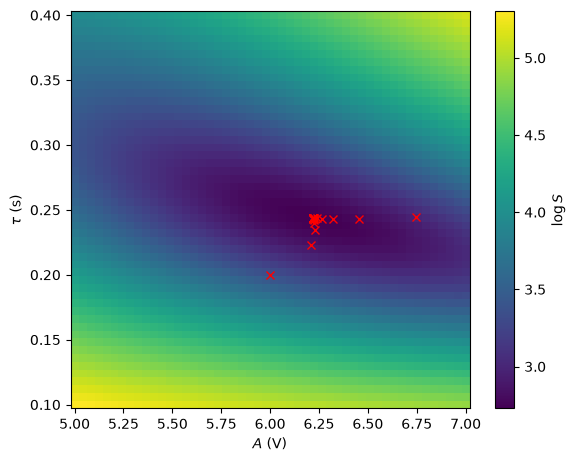

In [16]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

ax.plot(a[:,0], a[:,1], 'rx')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')
fig.tight_layout()

## h)

In der Vorlesung haben sie `lmfit` gesehen, eine Alternative ist `curve_fit` von `scipy.optimize` zu benutzen. Der Unterschied ist lediglich das Interface, im Hintergrund machen beide Methoden dasselbe. Verwenden Sie `curve_fit` um die Daten zu fitten und vergleichen Sie die Werte.

Falls Sie die Parameter zuvor als Vektoren an die Exponentialfunktion übergeben haben, ist es hier einfacher wenn Sie die Parameter einzeln übergeben. Sprich:

$$
f(x, \vec{a}) \qquad \Rightarrow \qquad f(x, a_1, a_2,...)
$$

In [19]:
from scipy.optimize import curve_fit


### Lösung

In [ ]:
# Definition der zu fittenden Funktion
def exp_cf(t, A, tau):
    return A*np.exp(-t/tau)

# Startwerte
a0 = [6, 0.2]

# Fitten
a_opt_cf, conv_cf = curve_fit(exp_cf, t, V, p0=a0, sigma=sigma, absolute_sigma=True)

# Berechnen der Standardabweichung
std_cf = np.sqrt(np.diag(conv_cf))

print('Berechnen der Werte mit curve_fit:')
print(u'A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.4f}s \u00b1 {:0.5f}s'
      .format(a_opt_cf[0], std_cf[0], a_opt_cf[1], std_cf[1]))
print('Berechnen der Werte mit der eigenen Funktion:')
print(u'A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0], a_opt[1], std[1]))

Berechnen der Werte mit curve_fit:
A = 6.22V ± 0.34V und tau = 0.2436s ± 0.01980s
Berechnen der Werte mit der eigenen Funktion:
A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
